# Exploratory Data Analysis — Bead Annotations

Sanity-checks the annotated dataset before we build a baseline model: how many beads per
image and condition, whether NT (control) images really do look like controls, and a visual
spot-check overlaying clicked points on a real image.

## Step 1: Load the combined annotations

This is the file produced by `annotate.py --combine` — one row per clicked bead, across all
60 images.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bioio import BioImage

annotations = pd.read_csv("../data/interim/all_annotations.csv")
print(f"{len(annotations)} total bead clicks across {annotations['image'].nunique()} images")
annotations.head()

766 total bead clicks across 60 images


,image,y,x
0,NI231117_SMI31-488_20x_DMSOx1_01.czi,802.647158,491.271422
1,NI231117_SMI31-488_20x_DMSOx1_01.czi,652.377653,469.597935
2,NI231117_SMI31-488_20x_DMSOx1_01.czi,541.120424,248.528375
3,NI231117_SMI31-488_20x_DMSOx1_01.czi,181.340551,329.442724
4,NI231117_SMI31-488_20x_DMSOx1_01.czi,140.883377,245.638577


## Step 2: Recover each image's condition

The annotation CSV only stores the bare filename (e.g. `NI240119_SMI31-488_20x_NT_01.czi`),
not which condition folder it came from. Rather than parsing condition names out of the
filename text (fragile — your filenames use different tokens like `NT` vs `HCl` for different
experiments), we rebuild the filename → condition mapping directly from how you organized
`data/raw/` into subfolders. This is more robust and will be reused as-is in Week 4.

In [3]:
raw_dir = Path("../data/raw")

# maps e.g. "NI240119_SMI31-488_20x_NT_01.czi" -> "NT"
filename_to_condition = {
    p.name: p.parent.name
    for p in raw_dir.rglob("*.czi")
}

annotations["condition"] = annotations["image"].map(filename_to_condition)

missing = annotations[annotations["condition"].isna()]
if len(missing):
    print(f"WARNING: {missing['image'].nunique()} images had no matching file in data/raw — check for renamed/moved files.")
else:
    print("All annotated images matched to a condition folder.")

annotations["condition"].value_counts()

All annotated images matched to a condition folder.


condition
high_beads    448
low_beads     250
control        68
Name: count, dtype: int64

## Step 3: Bead counts per image

Group by image to get one row per image with its total bead count and condition — this is
the table the rest of the analysis (and, later, model validation) works from.

In [4]:
counts_per_image = (
    annotations.groupby(["image", "condition"])
    .size()
    .reset_index(name="bead_count")
)

# Images with zero clicked beads never appear in a groupby on the annotations table
# (there's no row to group!) — add them back in explicitly so control images with
# genuinely zero beads aren't silently dropped from the analysis.
all_images = pd.DataFrame([
    {"image": p.name, "condition": p.parent.name} for p in raw_dir.rglob("*.czi")
])
counts_per_image = all_images.merge(counts_per_image, on=["image", "condition"], how="left")
counts_per_image["bead_count"] = counts_per_image["bead_count"].fillna(0).astype(int)

counts_per_image.groupby("condition")["bead_count"].describe()

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
control,20.0,3.4,2.521487,1.0,2.00,3.0,4.00,11.0
high_beads,20.0,22.4,6.548604,13.0,17.75,20.5,27.00,34.0
low_beads,20.0,12.5,3.872983,5.0,10.50,12.5,15.25,19.0


**Takeaway:** control conditions have a bead count close to 0, as expected. There is a clear separation between low_beads and high_beads conditions, which suggest condition effect on bead count.

## Step 4: Visualize the distribution by condition

A box plot shows the spread per condition in one view — easier to spot overlap or outliers
than the summary table alone.

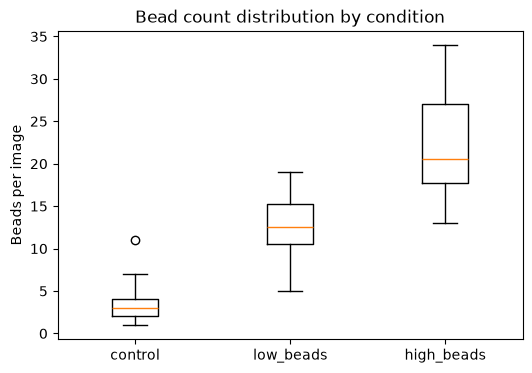

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
conditions_order = ["control", "low_beads", "high_beads"]
data_by_condition = [
    counts_per_image.loc[counts_per_image["condition"] == c, "bead_count"]
    for c in conditions_order
]
ax.boxplot(data_by_condition, tick_labels=conditions_order)
ax.set_ylabel("Beads per image")
ax.set_title("Bead count distribution by condition")
plt.show()

### Outliers:

There seems to be an outlier in the control condition with a bead count of 11 (we know this from the previous table "max").
Use the code below to find the outlier image name.

In [6]:
counts_per_image.loc[(counts_per_image["condition"] == "control") & (counts_per_image["bead_count"] == 11), ["image", "bead_count"]]

,image,bead_count
12,NI240119_SMI31-488_20x_HCl_03.czi,11


Visualize the outlier and check that the annotation was done correctly.

In [7]:
import napari
%gui qt

img = BioImage(str(next(raw_dir.rglob("NI240119_SMI31-488_20x_HCl_03.czi"))))
image = img.get_image_data("YX", C=1, T=0, Z=0)
pts = annotations.loc[annotations["image"] == "NI240119_SMI31-488_20x_HCl_03.czi", ["y", "x"]].values

viewer = napari.Viewer(title="Outlier check")
viewer.add_image(image, name="SMI-31", colormap="green")
viewer.add_points(pts, name="annotations", size=10, face_color="red", border_color="white")
napari.run()

## Step 5: Visual spot-check — overlay clicks on a real image

Numbers alone can hide problems (e.g. clicks landing off-center, or a condition mislabeled).
Pick one image and actually look at it.

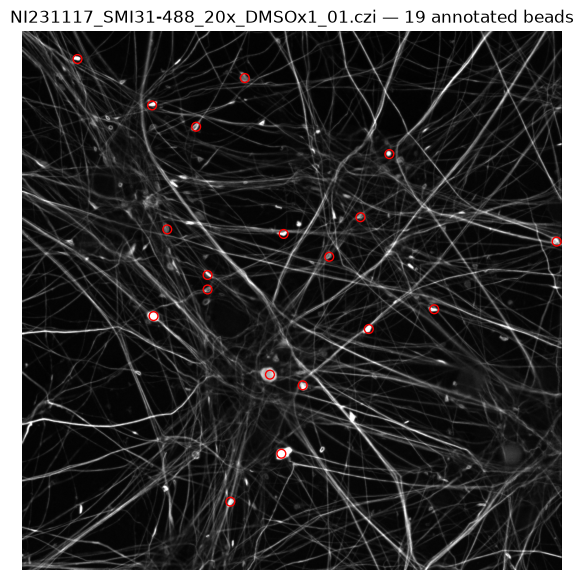

In [10]:
example_image_name = counts_per_image.loc[counts_per_image["condition"] == "high_beads", "image"].iloc[0]
example_path = next(raw_dir.rglob(example_image_name))

img = BioImage(str(example_path))
image = img.get_image_data("YX", C=1, T=0, Z=0)

example_points = annotations.loc[annotations["image"] == example_image_name, ["y", "x"]]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(image, cmap="gray")
ax.scatter(example_points["x"], example_points["y"], s=40, facecolors="none", edgecolors="red")
ax.set_title(f"{example_image_name} — {len(example_points)} annotated beads")
ax.axis("off")
plt.show()

**Takeaway:** red circles land on beads -> napari's point coordinates do not have significant pixel offset; no mis-clicks. Bead-like structures not pointed out are to small or not connected to neurites to be considered true beads.

## Step 6: Save summary stats for the data card

Write the per-condition summary out so the exact numbers are easy to copy into
`docs/data_card.md` section 3 — avoids re-typing numbers by hand and risking a transcription
error.

In [11]:
summary = counts_per_image.groupby("condition")["bead_count"].agg(["count", "sum", "mean", "std"])
summary.columns = ["n_images", "total_beads", "mean_beads_per_image", "std_beads_per_image"]
print(summary.round(1))

summary.round(1).to_csv("../docs/experiments/eda_summary_stats.csv")
print("\nSaved to docs/experiments/eda_summary_stats.csv")

            n_images  total_beads  mean_beads_per_image  std_beads_per_image
condition                                                                   
control           20           68                   3.4                  2.5
high_beads        20          448                  22.4                  6.5
low_beads         20          250                  12.5                  3.9

Saved to docs/experiments/eda_summary_stats.csv


## Next

With these numbers in hand: update `docs/data_card.md` section 3 with the real per-condition
counts (replacing the `_TBD_` placeholders), and section 7 (annotation protocol) with the
bead-center clicking convention used. Then on to the Week 3 baseline model.